# CNN Hyperparameter Tuning

## Objective

In this phase, we will investigate whether the CNN can be improved through hyperparameter optimization.

We will use a separate validation set for model selection while keeping the test set completely untouched.

### Experimental Protocol

- **Training set:** used to optimize model weights
- **Validation set:** used to select hyperparameters
- **Test set:** reserved for final evaluation

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt

import optuna

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [3]:
transform = transforms.ToTensor()

full_train_dataset = torchvision.datasets.MNIST(
    root="../../data/raw",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="../../data/raw",
    train=False,
    download=True,
    transform=transform
)

In [4]:
train_size = 50_000
validation_size = 10_000

train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [train_size, validation_size],
    generator=torch.Generator().manual_seed(42)
)

In [5]:
print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

Training samples: 50000
Validation samples: 10000
Test samples: 10000


In [6]:
def create_dataloaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, validation_loader

In [7]:
train_loader, validation_loader = create_dataloaders(64)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [8]:
class CNNModel(nn.Module):
    def __init__(
        self,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.0
    ):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                conv1_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                conv1_channels,
                conv2_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(
                conv2_channels * 7 * 7,
                10
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [9]:
model = CNNModel(
    conv1_channels=32,
    conv2_channels=64,
    dropout=0.0
).to(device)

print(model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.0, inplace=False)
    (2): Linear(in_features=3136, out_features=10, bias=True)
  )
)


In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [11]:
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    return correct / total

In [12]:
def train_model(
    conv1_channels=32,
    conv2_channels=64,
    dropout=0.0,
    learning_rate=0.001,
    batch_size=64,
    epochs=5
):
    train_loader, validation_loader = create_dataloaders(
        batch_size
    )

    model = CNNModel(
        conv1_channels=conv1_channels,
        conv2_channels=conv2_channels,
        dropout=dropout
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = []

    for epoch in range(epochs):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        validation_accuracy = evaluate(
            model,
            validation_loader
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "validation_accuracy": validation_accuracy
        })

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Loss: {train_loss:.4f} "
            f"- Val Acc: {validation_accuracy:.4%}"
        )

    return model, history

In [13]:
model, history = train_model(
    conv1_channels=32,
    conv2_channels=64,
    dropout=0.0,
    learning_rate=0.001,
    batch_size=64,
    epochs=5
)

Epoch 1/5 - Loss: 0.1988 - Val Acc: 97.5900%
Epoch 2/5 - Loss: 0.0612 - Val Acc: 98.2600%
Epoch 3/5 - Loss: 0.0429 - Val Acc: 98.5200%
Epoch 4/5 - Loss: 0.0345 - Val Acc: 98.2300%
Epoch 5/5 - Loss: 0.0277 - Val Acc: 98.6900%


## Hyperparameter Optimization

Optuna will search for a configuration that maximizes validation accuracy.

Each trial consists of:

1. Sampling a set of hyperparameters
2. Creating a new CNN with those hyperparameters
3. Training the model
4. Evaluating it on the validation set
5. Returning the validation accuracy to Optuna

The test set remains completely unused during optimization.

In [15]:
def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    conv1_channels = trial.suggest_categorical(
        "conv1_channels",
        [16, 32, 64]
    )

    conv2_channels = trial.suggest_categorical(
        "conv2_channels",
        [32, 64, 128]
    )

    dropout = trial.suggest_float(
        "dropout",
        0.0,
        0.5
    )

    model, history = train_model(
        conv1_channels=conv1_channels,
        conv2_channels=conv2_channels,
        dropout=dropout,
        learning_rate=learning_rate,
        batch_size=batch_size,
        epochs=5
    )

    validation_accuracy = history[-1]["validation_accuracy"]

    return validation_accuracy

In [16]:
study = optuna.create_study(
    direction="maximize"
)

[I 2026-08-23 14:41:10,105] A new study created in memory with name: no-name-a3ae6c21-6129-470f-b7c6-43b7c6f97e6e


In [17]:
study.optimize(
    objective,
    n_trials=20
)

Epoch 1/5 - Loss: 0.1643 - Val Acc: 97.4300%
Epoch 2/5 - Loss: 0.0622 - Val Acc: 98.2900%
Epoch 3/5 - Loss: 0.0483 - Val Acc: 98.5300%
Epoch 4/5 - Loss: 0.0398 - Val Acc: 98.5100%


[I 2026-08-23 14:43:19,943] Trial 0 finished with value: 0.9863 and parameters: {'learning_rate': 0.0016359427663757416, 'batch_size': 32, 'conv1_channels': 64, 'conv2_channels': 32, 'dropout': 0.0622111349675456}. Best is trial 0 with value: 0.9863.


Epoch 5/5 - Loss: 0.0345 - Val Acc: 98.6300%
Epoch 1/5 - Loss: 0.2196 - Val Acc: 97.7800%
Epoch 2/5 - Loss: 0.0901 - Val Acc: 98.2200%
Epoch 3/5 - Loss: 0.0714 - Val Acc: 98.5000%
Epoch 4/5 - Loss: 0.0606 - Val Acc: 98.7400%


[I 2026-08-23 14:44:35,919] Trial 1 finished with value: 0.9883 and parameters: {'learning_rate': 0.002201995651474963, 'batch_size': 64, 'conv1_channels': 32, 'conv2_channels': 32, 'dropout': 0.39858406326314827}. Best is trial 1 with value: 0.9883.


Epoch 5/5 - Loss: 0.0544 - Val Acc: 98.8300%
Epoch 1/5 - Loss: 0.3000 - Val Acc: 97.3200%
Epoch 2/5 - Loss: 0.0913 - Val Acc: 98.1300%
Epoch 3/5 - Loss: 0.0677 - Val Acc: 98.3400%
Epoch 4/5 - Loss: 0.0559 - Val Acc: 98.6100%


...

Epoch 5/5 - Loss: 0.0407 - Val Acc: 98.9300%
Epoch 1/5 - Loss: 0.2262 - Val Acc: 97.6400%
Epoch 2/5 - Loss: 0.1246 - Val Acc: 98.2600%
Epoch 3/5 - Loss: 0.1104 - Val Acc: 98.4700%
Epoch 4/5 - Loss: 0.1027 - Val Acc: 98.4500%


[I 2026-08-23 18:04:18,765] Trial 18 finished with value: 0.9834 and parameters: {'learning_rate': 0.009327437981760306, 'batch_size': 64, 'conv1_channels': 16, 'conv2_channels': 32, 'dropout': 0.49665519528406}. Best is trial 17 with value: 0.9893.


Epoch 5/5 - Loss: 0.1018 - Val Acc: 98.3400%
Epoch 1/5 - Loss: 0.2034 - Val Acc: 97.7200%
Epoch 2/5 - Loss: 0.0881 - Val Acc: 98.3100%
Epoch 3/5 - Loss: 0.0713 - Val Acc: 98.2600%
Epoch 4/5 - Loss: 0.0631 - Val Acc: 98.5000%


[I 2026-08-23 18:06:19,391] Trial 19 finished with value: 0.9864 and parameters: {'learning_rate': 0.0032428126161321057, 'batch_size': 64, 'conv1_channels': 32, 'conv2_channels': 64, 'dropout': 0.4183296020526118}. Best is trial 17 with value: 0.9893.


Epoch 5/5 - Loss: 0.0577 - Val Acc: 98.6400%


In [19]:
print("Best validation accuracy:")
print(study.best_value)

print("Best hyperparameters:")
print(study.best_params)

Best validation accuracy:
0.9893
Best hyperparameters:
{'learning_rate': 0.002576059342604795, 'batch_size': 64, 'conv1_channels': 16, 'conv2_channels': 128, 'dropout': 0.4839886412213569}


In [20]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_conv1_channels,params_conv2_channels,params_dropout,params_learning_rate,state
0,0,0.9863,2026-08-23 14:41:22.288246,2026-08-23 14:43:19.943407,0 days 00:01:57.655161,32,64,32,0.062211,0.001636,COMPLETE
1,1,0.9883,2026-08-23 14:43:19.943407,2026-08-23 14:44:35.919918,0 days 00:01:15.976511,64,32,32,0.398584,0.002202,COMPLETE
2,2,0.9861,2026-08-23 14:44:35.920919,2026-08-23 15:58:06.092313,0 days 01:13:30.171394,128,64,64,0.433313,0.000859,COMPLETE
3,3,0.9858,2026-08-23 15:58:06.093314,2026-08-23 17:33:33.054352,0 days 01:35:26.961038,128,64,64,0.058289,0.001323,COMPLETE
4,4,0.9774,2026-08-23 17:33:33.054352,2026-08-23 17:34:48.863597,0 days 00:01:15.809245,128,32,32,0.244865,0.000272,COMPLETE
5,5,0.9863,2026-08-23 17:34:48.864596,2026-08-23 17:37:00.294011,0 days 00:02:11.429415,64,32,128,0.148113,0.000558,COMPLETE
6,6,0.9794,2026-08-23 17:37:00.294011,2026-08-23 17:38:57.763454,0 days 00:01:57.469443,32,64,32,0.355808,0.000151,COMPLETE
7,7,0.9759,2026-08-23 17:38:57.764959,2026-08-23 17:40:35.146406,0 days 00:01:37.381447,128,32,32,0.000558,0.000302,COMPLETE
8,8,0.9752,2026-08-23 17:40:35.147913,2026-08-23 17:42:37.274146,0 days 00:02:02.126233,32,32,32,0.021542,0.000136,COMPLETE
9,9,0.9866,2026-08-23 17:42:37.274146,2026-08-23 17:45:44.934143,0 days 00:03:07.659997,32,32,128,0.015893,0.000409,COMPLETE


### Tuning Budget

For the initial hyperparameter search, every trial is trained for five epochs.

This keeps the computational cost of the search manageable and ensures that each configuration receives the same training budget.

This means the optimization is specifically searching for configurations that perform well within this five-epoch budget. Training duration will be investigated separately.

In [21]:
best_params = study.best_params

print(best_params)

{'learning_rate': 0.002576059342604795, 'batch_size': 64, 'conv1_channels': 16, 'conv2_channels': 128, 'dropout': 0.4839886412213569}


In [22]:
trials_df = study.trials_dataframe()

trials_df[
    [
        "number",
        "value",
        "params_learning_rate",
        "params_batch_size",
        "params_conv1_channels",
        "params_conv2_channels",
        "params_dropout"
    ]
].sort_values(
    "value",
    ascending=False
)

,number,value,params_learning_rate,params_batch_size,params_conv1_channels,params_conv2_channels,params_dropout
17,17,0.9893,0.002576,64,16,128,0.483989
1,1,0.9883,0.002202,64,32,32,0.398584
14,14,0.9882,0.002262,64,16,128,0.357033
12,12,0.9867,0.003214,64,16,128,0.192799
9,9,0.9866,0.000409,32,32,128,0.015893
19,19,0.9864,0.003243,64,32,64,0.418330
11,11,0.9864,0.004739,64,32,128,0.466511
0,0,0.9863,0.001636,32,64,32,0.062211
5,5,0.9863,0.000558,64,32,128,0.148113
2,2,0.9861,0.000859,128,64,64,0.433313


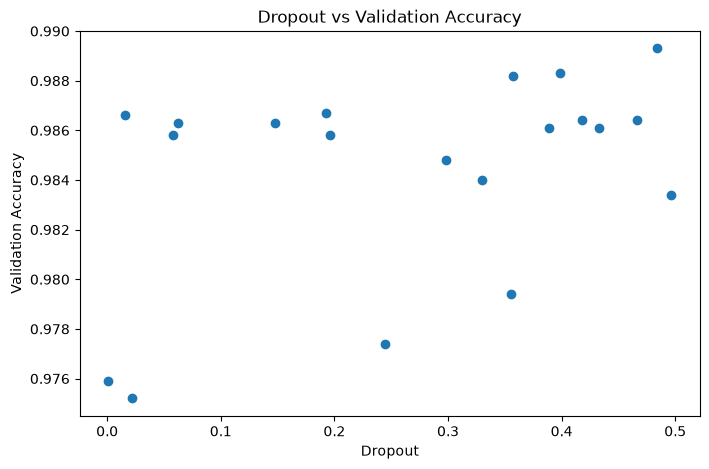

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    trials_df["params_dropout"],
    trials_df["value"]
)

plt.xlabel("Dropout")
plt.ylabel("Validation Accuracy")
plt.title("Dropout vs Validation Accuracy")

plt.show()

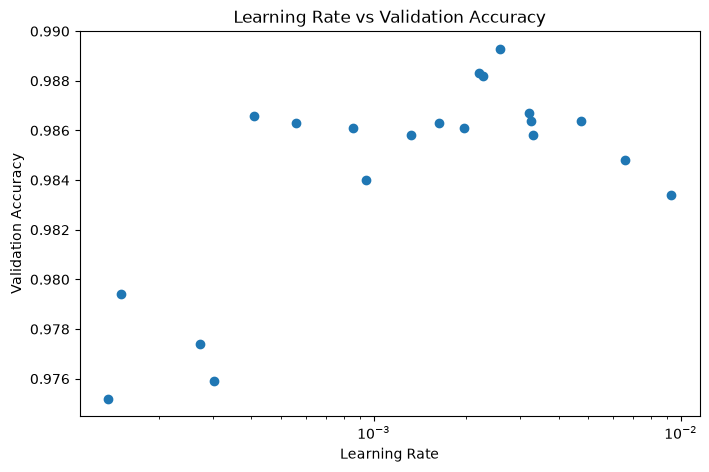

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    trials_df["params_learning_rate"],
    trials_df["value"]
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy")
plt.title("Learning Rate vs Validation Accuracy")

plt.show()

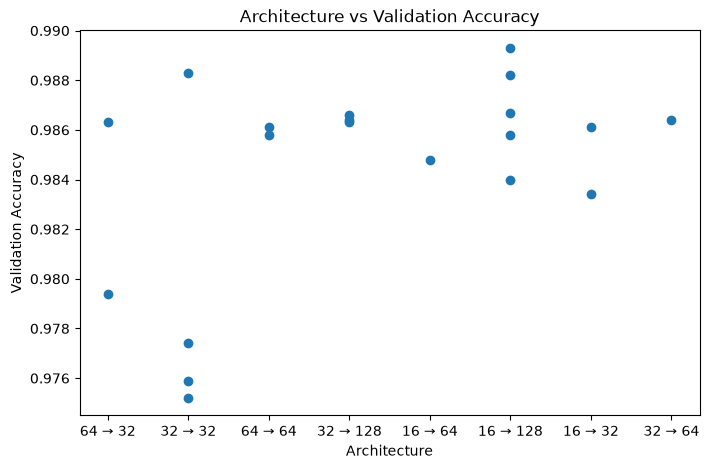

In [25]:
plt.figure(figsize=(8, 5))

architectures = (
    trials_df["params_conv1_channels"].astype(str)
    + " → "
    + trials_df["params_conv2_channels"].astype(str)
)

plt.scatter(
    architectures,
    trials_df["value"]
)

plt.xlabel("Architecture")
plt.ylabel("Validation Accuracy")
plt.title("Architecture vs Validation Accuracy")

plt.show()

In [27]:
final_train_loader = DataLoader(
    full_train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False
)

In [28]:
final_model = CNNModel(
    conv1_channels=best_params["conv1_channels"],
    conv2_channels=best_params["conv2_channels"],
    dropout=best_params["dropout"]
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_params["learning_rate"]
)

In [29]:
model, history = train_model(
    conv1_channels=best_params["conv1_channels"],
    conv2_channels=best_params["conv2_channels"],
    dropout=best_params["dropout"],
    learning_rate=best_params["learning_rate"],
    batch_size=best_params["batch_size"],
    epochs=15
)

Epoch 1/15 - Loss: 0.1693 - Val Acc: 97.9300%
Epoch 2/15 - Loss: 0.0669 - Val Acc: 98.2500%
Epoch 3/15 - Loss: 0.0524 - Val Acc: 98.5200%
Epoch 4/15 - Loss: 0.0443 - Val Acc: 98.4900%
Epoch 5/15 - Loss: 0.0390 - Val Acc: 98.8800%
Epoch 6/15 - Loss: 0.0350 - Val Acc: 99.0600%
Epoch 7/15 - Loss: 0.0308 - Val Acc: 98.9900%
Epoch 8/15 - Loss: 0.0281 - Val Acc: 99.0900%
Epoch 9/15 - Loss: 0.0264 - Val Acc: 98.9500%
Epoch 10/15 - Loss: 0.0272 - Val Acc: 98.7600%
Epoch 11/15 - Loss: 0.0231 - Val Acc: 98.9800%
Epoch 12/15 - Loss: 0.0219 - Val Acc: 98.9600%
Epoch 13/15 - Loss: 0.0192 - Val Acc: 98.9600%
Epoch 14/15 - Loss: 0.0215 - Val Acc: 99.0900%
Epoch 15/15 - Loss: 0.0177 - Val Acc: 99.0700%


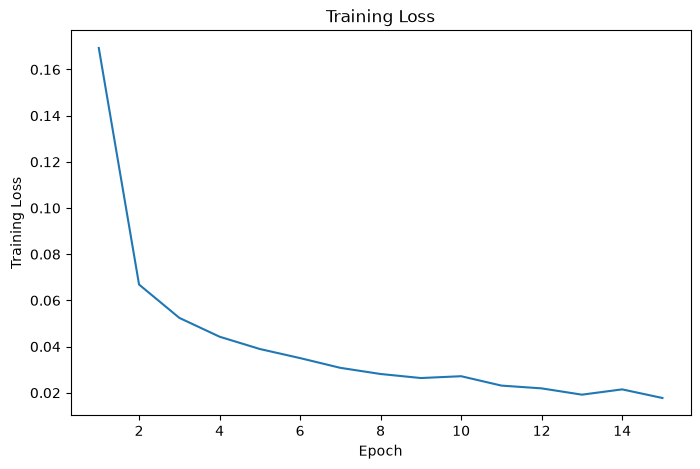

In [31]:
epochs = [x["epoch"] for x in history]
train_losses = [x["train_loss"] for x in history]
val_accuracies = [x["validation_accuracy"] for x in history]

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")

plt.show()

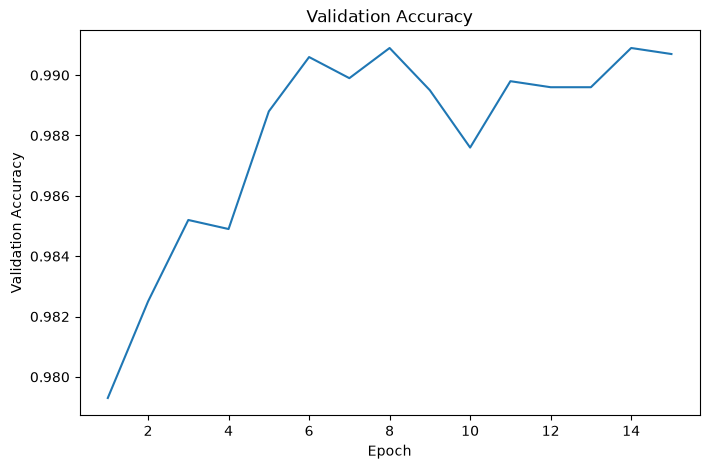

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, val_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy")

plt.show()

In [33]:
final_model = CNNModel(
    conv1_channels=best_params["conv1_channels"],
    conv2_channels=best_params["conv2_channels"],
    dropout=best_params["dropout"]
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_params["learning_rate"]
)

In [34]:
final_history = []

for epoch in range(8):

    train_loss = train_one_epoch(
        final_model,
        final_train_loader,
        criterion,
        optimizer
    )

    final_history.append(train_loss)

    print(
        f"Epoch {epoch + 1}/8 "
        f"- Loss: {train_loss:.4f}"
    )

Epoch 1/8 - Loss: 0.1558
Epoch 2/8 - Loss: 0.0621
Epoch 3/8 - Loss: 0.0500
Epoch 4/8 - Loss: 0.0434
Epoch 5/8 - Loss: 0.0384
Epoch 6/8 - Loss: 0.0337
Epoch 7/8 - Loss: 0.0328
Epoch 8/8 - Loss: 0.0281


In [35]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

final_test_accuracy = evaluate(
    final_model,
    test_loader
)

print(f"Final test accuracy: {final_test_accuracy:.4%}")

Final test accuracy: 99.0700%


# Final Results

## Hyperparameter Optimization

The initial CNN achieved a test accuracy of **98.89%**.

Hyperparameter optimization was performed using a separate validation set. The best configuration found during the 20-trial search achieved **98.93% validation accuracy** after five epochs.

The selected configuration was:

| Hyperparameter | Value |
|---|---:|
| Learning rate | 0.002576 |
| Batch size | 64 |
| Conv1 channels | 16 |
| Conv2 channels | 128 |
| Dropout | 0.484 |

The selected configuration was subsequently evaluated. Its validation accuracy reached a maximum of **99.09%** during this analysis.

After selecting the training configuration, the model was retrained using all 60,000 available training samples and evaluated once on the previously untouched test set.

The final test accuracy was **99.07%**.

In [36]:
sum(p.numel() for p in final_model.parameters() if p.requires_grad)

81450

## Comparison

| Model | Parameters | Test Accuracy |
|---|---:|---:|
| Fully Connected Baseline | 101,770 | 97.04% |
| Initial CNN | 50,186 | 98.89% |
| Tuned CNN | 81450 | 99.07% |

The tuned CNN improved upon the initial CNN by **0.18 percentage points**, reducing the test error rate from 1.11% to 0.93%.

Although the absolute accuracy improvement is relatively small, the reduction in error rate is approximately 16%.

The results demonstrate that the initial CNN architecture already provided a substantial improvement over the fully connected baseline, while hyperparameter optimization provided an additional but smaller improvement.

In [37]:
import os

model_path = "../../models/cnn_mnist.pt"

os.makedirs("../../models", exist_ok=True)

torch.save(
    final_model.state_dict(),
    model_path
)

print(f"Model saved to: {model_path}")

Model saved to: ../../models/cnn_mnist.pt
